# Training model on GPU


***

### Steps for GPU Training

## 1. **Check for GPU Availability**
Verify GPU presence before training to select the correct device.

```python
import torch

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
```

This ensures compatibility across environments.

##2. **Move the Model to GPU**
Transfer the model to GPU (`cuda` or `cpu`) so all computations occur on the selected device.

```python
model = myModel()  # Replace with your model
model = model.to(device)  # Move model to GPU
```

Model parameters and buffers are now on the accelerator.

##3. **Modify Training Loop by Moving Data to GPU**
Ensure both data and labels are on the same GPU before processing.

```python
for batch_features, batch_labels in train_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)
    # Forward pass, loss, backward, etc.
```

This prevents device‑mismatch errors during training.

##4. **Modify Evaluation Loop – Move Data to GPU**
Move test data to GPU for evaluation. Disable gradient calculations using `torch.no_grad()` for efficiency.

```python
for batch_features, batch_labels in test_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)
    with torch.no_grad():
        # Evaluation forward pass
```

Gradients are not computed, saving memory and time.

##5. **Optimize GPU Usage**

a. **Use Larger Batch Sizes**
Larger batch sizes better utilize GPU memory and reduce computation time per epoch.

```python
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)
```

Increases throughput on high‑memory GPUs.

b. **Enable DataLoader Pinning**
Use `pin_memory=True` in `DataLoader` to speed up data transfer from CPU to GPU.

```python
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, pin_memory=True)
```


In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [84]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device:{device}")

Using Device:cuda


In [85]:
df = pd.read_csv("fashion-mnist_train.csv")

In [86]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [87]:
df.shape

(60000, 785)

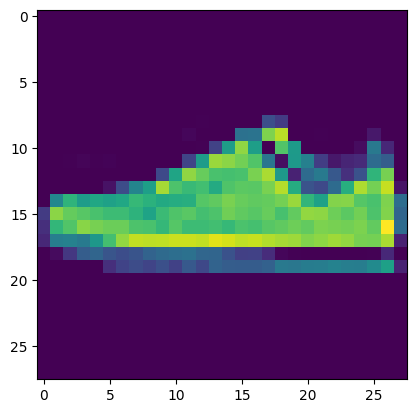

In [88]:
img = df.iloc[635,1:].values.reshape(28,28) # reshaping the images from 28 x 28
plt.imshow(img)

In [89]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [90]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [91]:
y

array([2, 9, 6, ..., 8, 8, 7])

In [92]:
import numpy as np
X = np.nan_to_num(X,nan=0.0)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [94]:
# performing the scailing
X_train = X_train/255.0
X_test = X_test/255.0

In [95]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [96]:
X_test

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.82745098, 0.4       ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [97]:
# Create a CustomDataset class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self,index):

    return self.features[index], self.labels[index]

In [98]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [99]:
len(train_dataset)

48000

In [100]:
train_dataset[420]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [101]:
test_dataset = CustomDataset(X_test,y_test)

In [102]:
len(test_dataset)

12000

In [103]:
test_dataset[43]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0078, 0.0039, 0.0000,
         0.0000, 0.0000, 0.3255, 0.1451, 0.0000, 0.0000, 0.0000, 0.3137, 0.2275,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0078, 0.2627, 0.5255, 0.6314, 0.5843, 0.6196, 0.6902, 0.7569, 0.5882,
         0.3098, 0.3255, 0.2275, 0.0549, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0941,
         0.3333, 0.4118, 0.4588, 0.4431, 0.3647, 0.3098, 0.3804, 0.3294, 0.2588,
         0.1804, 0.2980, 0.3059, 0.3843, 0.4157, 0.2745, 0.0784, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3569,
         0.5176, 0.3647, 0.3608, 0.3176, 0.3804, 0.3647, 0.2980, 0.3412, 0.3059,
         0.3137, 0.2941, 0.2784, 0.2157, 0.2392, 0.2745, 0.3412, 0.3294, 0.1529,
         0.0000, 0.0039, 0.0

In [104]:
# create train and test loader object
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True) # pin_memory is simply used to speed up the training on GPU
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True) # while predicting, you usually dont wanna shuffle the data.

# Our proposed architecure

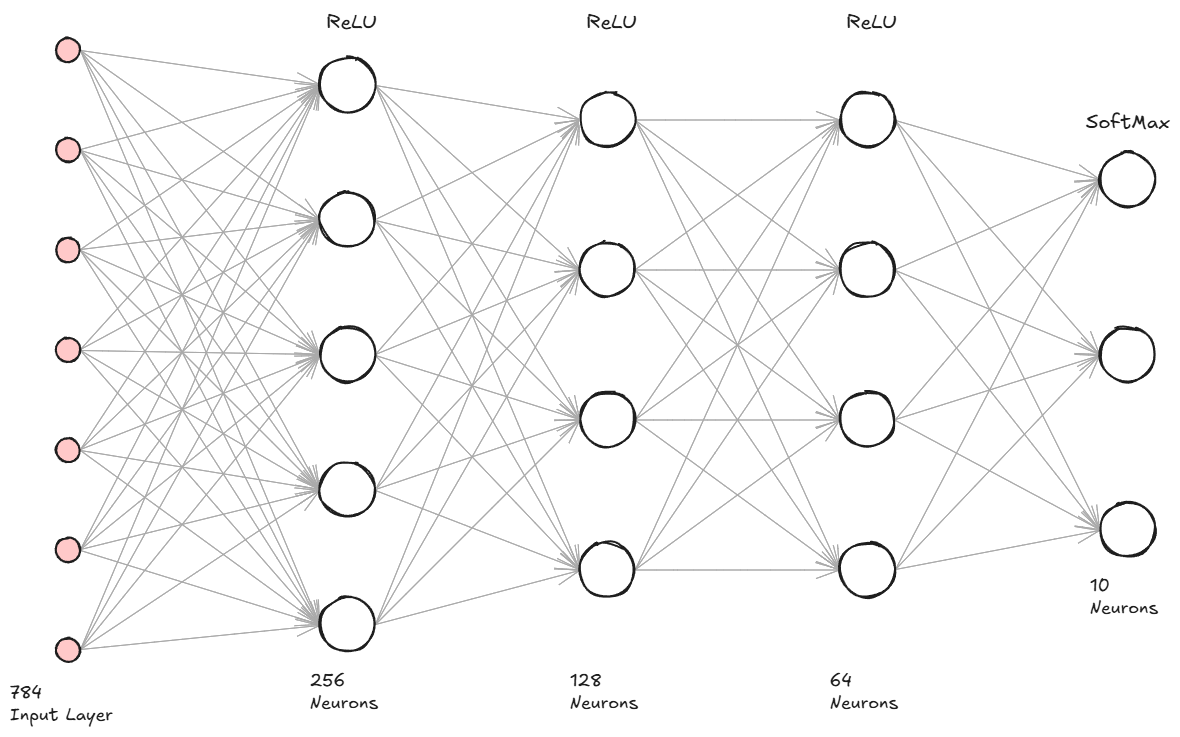

In [105]:
# Define a NN class
class vrajNN(nn.Module):

  def __init__(self, num_features):

    super().__init__() # invoking the parent constructor

    self.model = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10) # here we dont need to add softmax, because pytorch has internally made it by default.
    )

  def forward(self, X):

    return self.model(X)

In [106]:
# setting learning rate and epochs

epochs = 100
learning_rate = 0.1

In [107]:
# instantiate the model
model = vrajNN(X_train.shape[1]) # X_train.shape[1] is the no. of features
model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [108]:
# training loop
for epoch in range(epochs):

  total_epoch_loss = 0 # setting up a variable in order to track the loss across each epoch

  for batch_features, batch_labels in train_loader:

    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # loss calculate
    loss = criterion(outputs, batch_labels)

    # back propagation
    optimizer.zero_grad() # clearing out gradients
    loss.backward()

    # update weights
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_loader)
  print(f'Epoch: {epoch+1}, Loss : {avg_loss}')

Epoch: 1, Loss : 0.7060365240176518
Epoch: 2, Loss : 0.4371606754412254
Epoch: 3, Loss : 0.38561434897283714
Epoch: 4, Loss : 0.3541624050711592
Epoch: 5, Loss : 0.3320050648500522
Epoch: 6, Loss : 0.31412420246005057
Epoch: 7, Loss : 0.3009684733649095
Epoch: 8, Loss : 0.28829104580730197
Epoch: 9, Loss : 0.27660183452193937
Epoch: 10, Loss : 0.26516954160978395
Epoch: 11, Loss : 0.2568281030555566
Epoch: 12, Loss : 0.2478436535410583
Epoch: 13, Loss : 0.24015813497702282
Epoch: 14, Loss : 0.233323140223821
Epoch: 15, Loss : 0.22476870383198064
Epoch: 16, Loss : 0.2203025130505363
Epoch: 17, Loss : 0.21146884500111143
Epoch: 18, Loss : 0.20687552653377256
Epoch: 19, Loss : 0.2025120305220286
Epoch: 20, Loss : 0.19575564852605262
Epoch: 21, Loss : 0.19025814797791343
Epoch: 22, Loss : 0.18471723191440106
Epoch: 23, Loss : 0.17883994557832678
Epoch: 24, Loss : 0.17967882694583387
Epoch: 25, Loss : 0.17170906130348643
Epoch: 26, Loss : 0.17045985704349975
Epoch: 27, Loss : 0.165144017483

In [109]:
loss.item()

0.08885185420513153

In [110]:
# set model to the evaluation mode
model.eval() # we have to explicitly tell the model that it's in eval mode because sometimes, some models might behave different while training and testing. for ex, dropouts.

vrajNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [111]:
# Evaluation code
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)  # Calculates class with max probability

        total += batch_labels.shape[0]      # Accumulate total samples

        correct += (predicted == batch_labels).sum().item()  # Count correct predictions

print(f"Accuracy: {correct / total:.4f}")  # or just correct/total

Accuracy: 0.8926
